#  טעינה, ניקוי, ארגון וניתוח נתוני מכירות בערוצים שונים
 מטרת הפרויקט להסיק מסקנות עסקיות לכל ניתוח ולמצוא פתרונות
 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import rcParams
from bidi.algorithm import get_display

# font שתומך בעברית
rcParams['font.family'] = 'DejaVu Sans'

# פונקציה שמתקנת עברית + אנגלית
def fix_text(text):
    return get_display(text)


## טעינת נתונים

In [2]:
Sales_Revenue = pd.read_csv(r"C:\Users\ariel\Downloads\test.csv")
print(f"צורת הנתונים: {Sales_Revenue.shape}")
Sales_Revenue.head()

צורת הנתונים: (6000, 16)


,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value
0,18001,2010-11-14 13:39:00,North,Social Media,Storage,Premium,16.50,1.65,0.2763,845.0,16185,0.0637,6.32,0.366025,30.0,4500.10
1,18002,2010-10-10 11:53:00,North,Affiliate,Storage,Premium,15.00,1.25,0.1694,525.0,5684,0.0213,2.75,-0.366025,21.0,15.00
2,18003,2010-10-31 11:06:00,North,Social Media,General,Premium,325.44,3.39,0.3736,362.0,11490,0.0070,0.58,-0.366025,NaN,1818.31
3,18004,2011-02-07 14:51:00,South,Social Media,General,Premium,7.80,0.65,0.3246,138.0,3046,0.0686,1.50,1.366025,7.0,4442.36
4,18005,2011-05-16 14:24:00,north,Search,General,Premium,458.00,4.58,0.2625,309.0,8983,0.0231,9.19,-0.366025,28.0,400409.80


## בדיקת נתונים

In [3]:
Sales_Revenue.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       6000 non-null   int64  
 1   date                     6000 non-null   str    
 2   region                   6000 non-null   str    
 3   channel                  6000 non-null   str    
 4   product_category         6000 non-null   str    
 5   customer_segment         6000 non-null   str    
 6   ad_spend                 5771 non-null   float64
 7   price                    6000 non-null   float64
 8   discount_rate            5720 non-null   float64
 9   market_reach             5765 non-null   float64
 10  impressions              6000 non-null   int64  
 11  click_through_rate       5738 non-null   float64
 12  competition_index        5754 non-null   float64
 13  seasonality_index        6000 non-null   float64
 14  campaign_duration_days   5551 non-n

In [4]:
Sales_Revenue.describe().round(2)

,id,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value
count,6000.00,5771.00,6000.00,5720.00,5765.00,6000.00,5738.00,5754.00,6000.00,5551.00,5735.00
mean,21000.50,44.90,5.24,0.23,323.19,7320.87,0.06,4.00,-0.02,36.28,11089.57
std,1732.20,189.05,20.08,0.15,247.36,7613.08,0.05,2.01,0.92,27.22,38838.38
min,18001.00,0.00,0.00,0.00,1.00,-18129.00,0.00,0.03,-1.37,7.00,0.00
25%,19500.75,4.95,1.25,0.11,141.00,2474.00,0.02,2.41,-1.00,14.00,559.40
50%,21000.50,12.60,1.95,0.20,269.00,5151.50,0.04,3.83,0.37,28.00,1745.38
75%,22500.25,19.80,3.75,0.32,439.00,9701.75,0.08,5.46,1.00,60.00,5319.72
max,24000.00,2500.00,246.83,0.60,1490.00,118268.00,0.33,9.59,1.37,90.00,594023.99


## בדיקת ערכים חסרים

In [5]:
missing = Sales_Revenue.isna().sum()
missing[missing > 0]

ad_spend                   229
discount_rate              280
market_reach               235
click_through_rate         262
competition_index          246
campaign_duration_days     449
customer_lifetime_value    265
dtype: int64

## מילוי ערכים חסרים

In [6]:
data_missing = [
    "ad_spend", "discount_rate", "market_reach",
    "click_through_rate", "competition_index",
    "campaign_duration_days", "customer_lifetime_value"
]
for col in data_missing:
    Sales_Revenue[col] = Sales_Revenue[col].fillna(Sales_Revenue[col].median())

print("ערכים חסרים לאחר מילוי:", Sales_Revenue.isna().sum())
# ממלא את השדות הריקים בחציון לאחר בדיקת הנתונים

ערכים חסרים לאחר מילוי: id                         0
date                       0
region                     0
channel                    0
product_category           0
customer_segment           0
ad_spend                   0
price                      0
discount_rate              0
market_reach               0
impressions                0
click_through_rate         0
competition_index          0
seasonality_index          0
campaign_duration_days     0
customer_lifetime_value    0
dtype: int64


## ניקוי נתונים — תיקון שמות (שיפור: str.strip().str.title())

In [7]:
# שיפור: במקום replace_map ידני — שימוש ב-strip ו-title לאיחוד אוטומטי
Sales_Revenue['channel'] = Sales_Revenue['channel'].str.strip().str.replace('_', ' ').str.title()
Sales_Revenue['region']  = Sales_Revenue['region'].str.strip().str.title()

# תיקון שגיאות כתיב שנותרו
Sales_Revenue['channel'] = Sales_Revenue['channel'].replace({'Socail Media': 'Social Media','Socialmedia': 'Social Media'})
Sales_Revenue['region']  = Sales_Revenue['region'].replace({'Nort': 'North', 'Norht': 'North'})

print("ערוצים לאחר ניקוי:", Sales_Revenue['channel'].unique())
print("אזורים לאחר ניקוי:", Sales_Revenue['region'].unique())

ערוצים לאחר ניקוי: <StringArray>
['Social Media', 'Affiliate', 'Search', 'Tv', 'Influencer', 'Email']
Length: 6, dtype: str
אזורים לאחר ניקוי: <StringArray>
['North', 'South', 'West', 'East', 'Central']
Length: 5, dtype: str


In [8]:
Sales_Revenue['channel'].value_counts()

channel
Social Media    1448
Search          1231
Email           1180
Affiliate        908
Tv               629
Influencer       604
Name: count, dtype: int64

In [9]:
Sales_Revenue['region'].value_counts()

region
North      5795
East        133
West         30
Central      28
South        14
Name: count, dtype: int64

## עיבוד תאריכים

In [10]:
Sales_Revenue['date']        = pd.to_datetime(Sales_Revenue['date'], format='mixed', dayfirst=True)
Sales_Revenue['year']        = Sales_Revenue['date'].dt.year
Sales_Revenue['month']       = Sales_Revenue['date'].dt.month
Sales_Revenue['quarter']     = Sales_Revenue['date'].dt.quarter
Sales_Revenue['day_of_week'] = Sales_Revenue['date'].dt.day_name()
Sales_Revenue['hour']        = Sales_Revenue['date'].dt.hour
Sales_Revenue['year_month']  = Sales_Revenue['date'].dt.to_period('M')

print("שנים בנתונים:", sorted(Sales_Revenue['year'].unique()))

שנים בנתונים: [np.int32(2009), np.int32(2010), np.int32(2011)]


---
## חישוב מדדים עסקיים חדשים: Revenue ו-ROI
### שאלה עסקית: כמה הכנסה בפועל מניב כל ערוץ

In [11]:
# חישוב הכנסה נטו לאחר הנחה
Sales_Revenue['revenue'] = Sales_Revenue['price'] * (1 - Sales_Revenue['discount_rate'])

# ROI = (הכנסה - הוצאה פרסום) / הוצאה פרסום
Sales_Revenue['roi'] = (
    (Sales_Revenue['revenue'] - Sales_Revenue['ad_spend'])
    / Sales_Revenue['ad_spend'].replace(0, np.nan)
)

print(Sales_Revenue[['revenue','roi']].describe().round(2))

       revenue      roi
count  6000.00  6000.00
mean      3.99    -0.38
std      15.13     5.18
min       0.00    -1.00
25%       0.83    -0.93
50%       1.52    -0.85
75%       2.95    -0.59
max     222.17   187.00


              revenue   roi
channel                    
Influencer       4.10 -0.15
Social Media     4.48 -0.25
Email            3.43 -0.31
Affiliate        4.31 -0.43
Search           3.90 -0.54
Tv               3.55 -0.65


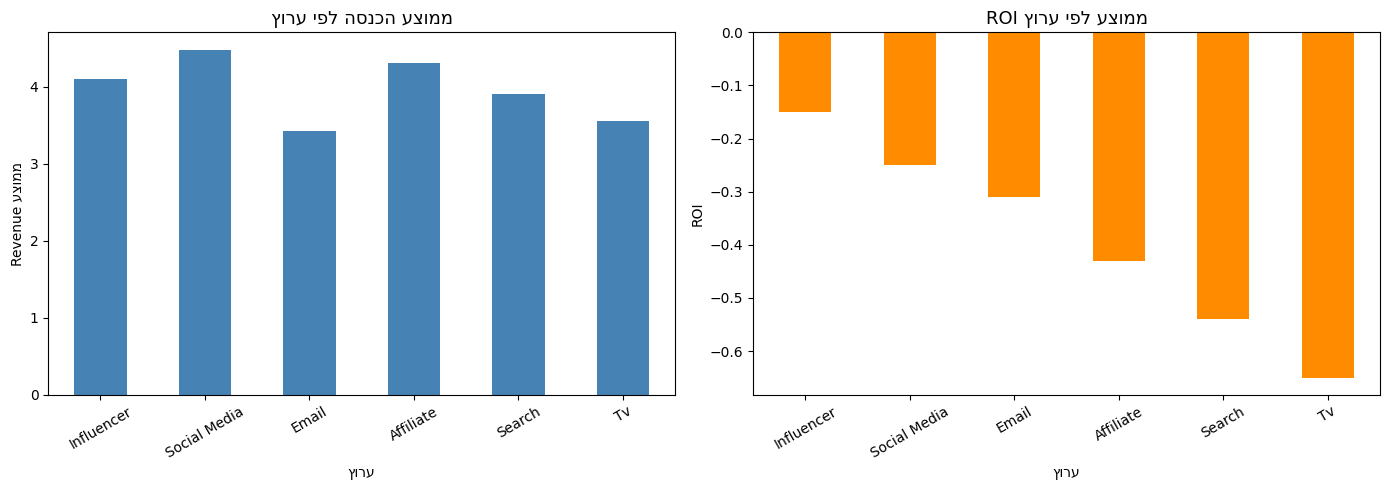

In [12]:
roi_channel = Sales_Revenue.groupby('channel')[['revenue','roi']].mean().round(2).sort_values('roi', ascending=False)
print(roi_channel)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

roi_channel['revenue'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title(fix_text('ממוצע הכנסה לפי ערוץ'), fontsize=13)
axes[0].set_xlabel(fix_text('ערוץ'))
axes[0].set_ylabel(fix_text('Revenue ממוצע'))
axes[0].tick_params(axis='x', rotation=30)

roi_channel['roi'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title(fix_text('ROI ממוצע לפי ערוץ'), fontsize=13)
axes[1].set_xlabel(fix_text('ערוץ'))
axes[1].set_ylabel(fix_text('ROI'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### ממצא והמלצה עסקית — Revenue ו-ROI
- יש צורך לבדוק כדאיות המשך השקעה הערוצים כמו רשתות חברתיות
- ערוצים עם תשואה גבוה אך החזר השקעה נמוך — ייתכן שהוצאות הפרסום גבוהות מדי יחסית להכנסה
- **המלצה:** לרכז את תקציב הפרסום בערוצים בעלי החזר השקעה גבוה, ולבחון מחדש את ההשקעה בערוצים בעלי נמוך

---
## ניתוח עונתיות —  הכנסות לפי חודש ושנה
### שאלה עסקית: מתי כדאי להשיק קמפיינים? האם יש חודשים חזקים עקביים?

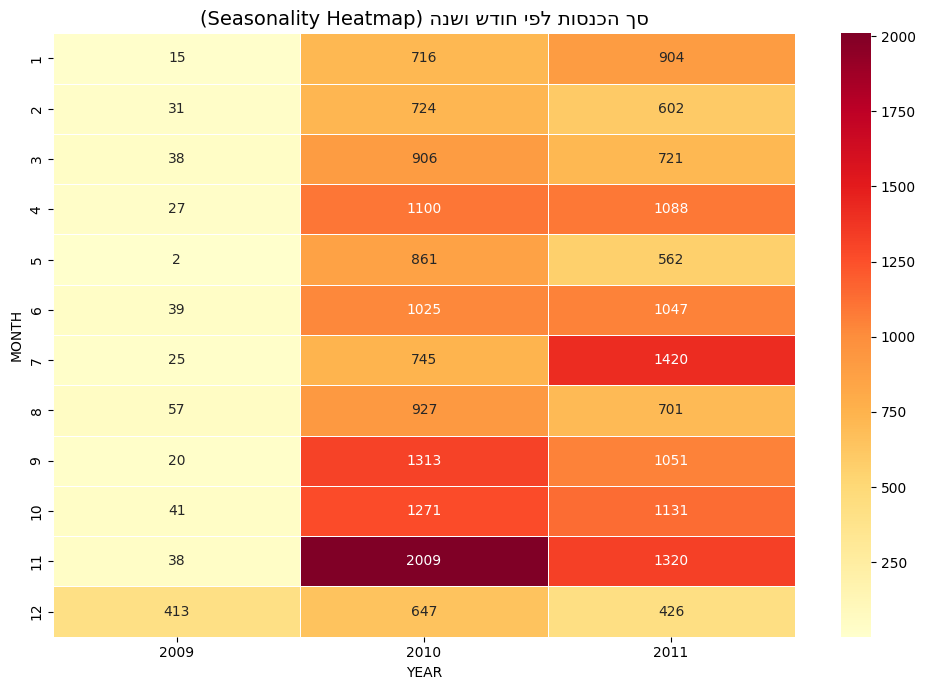

In [13]:
monthly_revenue = Sales_Revenue.groupby(['year', 'month'])['revenue'].sum().reset_index()
pivot_seasonal = monthly_revenue.pivot(index='month', columns='year', values='revenue')

plt.figure(figsize=(10, 7))
sns.heatmap(
    pivot_seasonal,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5
)
plt.title(fix_text('סך הכנסות לפי חודש ושנה (Seasonality Heatmap)'), fontsize=14)
plt.xlabel('YEAR')
plt.ylabel('MONTH')
plt.tight_layout()
plt.show()

### ממצא והמלצה עסקית — עונתיות
- ניתן לזהות אם חודשי  (אוקטובר–דצמבר) מניבים הכנסות גבוהות יותר באופן עקבי
- **המלצה:** להגדיל תקציב פרסום לפני החודשים החזקים, ולהפחית בחודשים החלשים

---
## ניתוח ערך של הלקוח לחברה. מגמה שנתית לפי ערוץ
### שאלה עסקית: האם ערך הלקוח גדל לאורך זמן? אילו ערוצים מראים צמיחה?

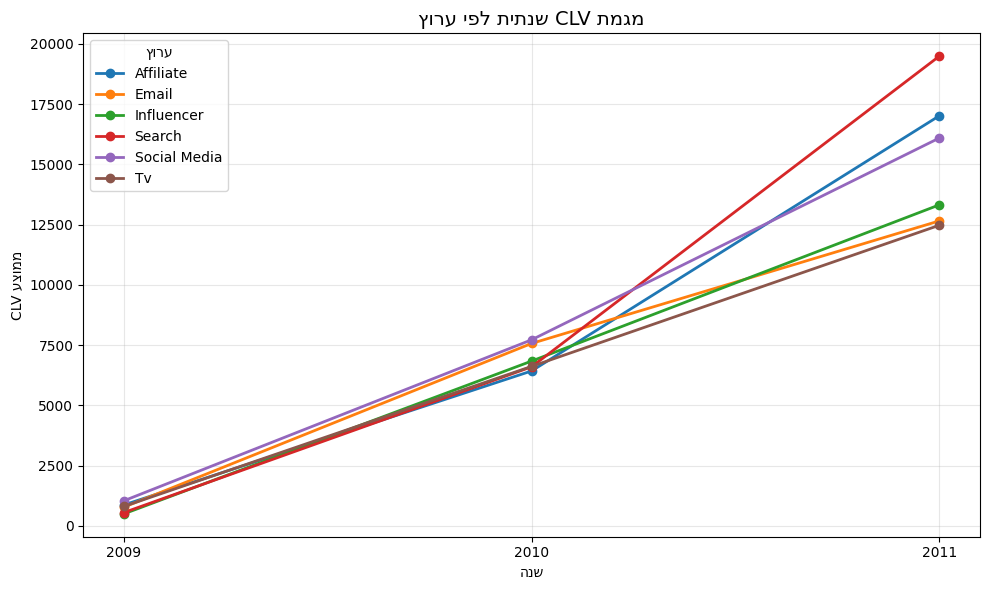

In [14]:
yearly_clv = Sales_Revenue.groupby(['year', 'channel'])['customer_lifetime_value'].mean().unstack()

plt.figure(figsize=(10, 6))
for channel in yearly_clv.columns:
    plt.plot(yearly_clv.index, yearly_clv[channel], marker='o', linewidth=2, label=channel)

plt.title(fix_text('מגמת CLV שנתית לפי ערוץ'), fontsize=14)
plt.xlabel(fix_text('שנה'))
plt.ylabel(fix_text('CLV ממוצע'))
plt.xticks(yearly_clv.index)
plt.legend(title=fix_text('ערוץ'))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### ממצא והמלצה עסקית — מגמת ערך של הלקוח לחברה
- CLV עולה בצורה חדה בין 2009 ל-2011 — סימן לצמיחה בריאה
- הערוץ המוביל בצמיחה ראוי להשקעה נוספת
- **המלצה:** לזהות מה מגמה בערוצים ולשקול הורדת השקעה נוספת לערוצים החלשים

---

### שאלה עסקית: אילו ערוצים עובדים הכי טוב על כל סגמנט לקוח?

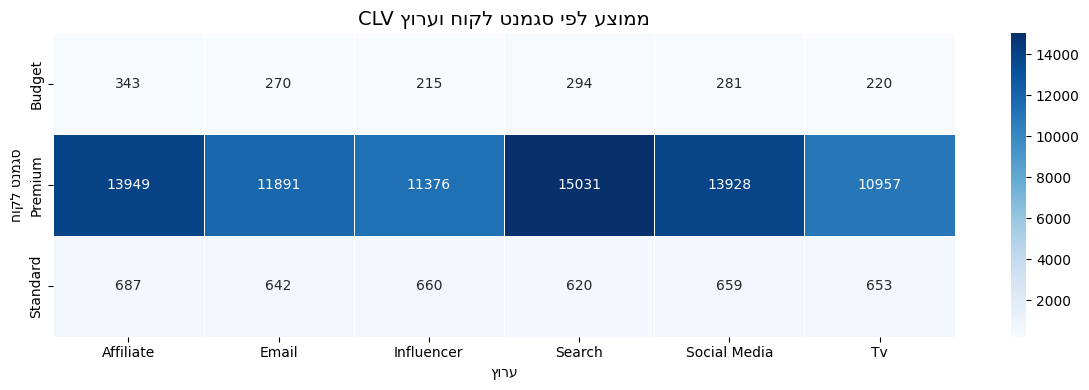

In [15]:
pivot_seg_channel = Sales_Revenue.pivot_table(
    values='customer_lifetime_value',
    index='customer_segment',
    columns='channel',
    aggfunc='mean'
).round(0)

plt.figure(figsize=(12, 4))
sns.heatmap(
    pivot_seg_channel,
    annot=True, fmt='.0f', cmap='Blues',
    linewidths=0.5
)
plt.title(fix_text('CLV ממוצע לפי סגמנט לקוח וערוץ'), fontsize=14)
plt.xlabel(fix_text('ערוץ'))
plt.ylabel(fix_text('סגמנט לקוח'))
plt.tight_layout()
plt.show()

### ממצא והמלצה עסקית — Segment via Channel
- לקוחות Premium מגיבים טוב לערוצים מסוימים — כדאי להתמקד בהם
- לקוחות Budget מגיבים לערוצים זולים יותר כמו Social Media
- **המלצה:** לפצל קמפיינים לפי סגמנט, ולהפנות כל סגמנט לערוץ האפקטיבי ביותר עבורו

---
## ניתוח לפי ערוץ — CLV סטטיסטיקות
### שאלה עסקית: מה הפיזור של ערך הלקוח בכל ערוץ?

In [16]:
channel_analysis = Sales_Revenue.groupby('channel')['customer_lifetime_value'].agg(
    ['mean',  'std', 'min', 'max']
).round(2).sort_values('mean', ascending=False)
print(channel_analysis)

                  mean       std    min        max
channel                                           
Search        12052.05  42827.00   4.25  499899.20
Affiliate     11274.45  40379.47   1.95  514435.34
Social Media  11256.79  40105.57   0.00  594023.99
Email          9664.41  30520.05  12.50  403806.16
Influencer     9356.78  36216.35   1.68  494695.63
Tv             8954.91  33687.95   5.07  592393.07


C:\Users\ariel\AppData\Local\Temp\ipykernel_14672\647123961.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


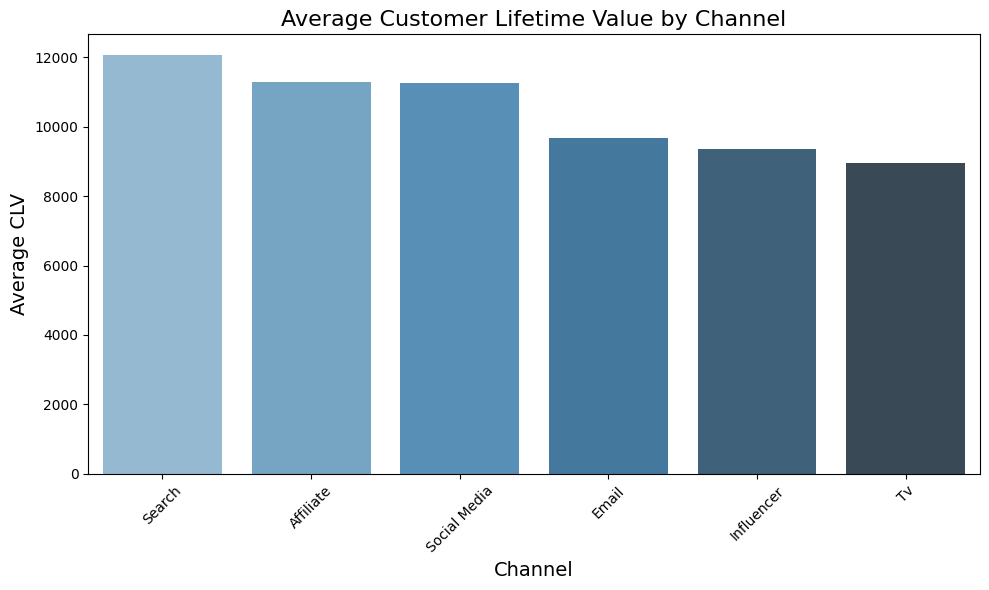

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=channel_analysis.reset_index(),
    x='channel',
    y='mean',
    palette='Blues_d'
)

plt.title('Average Customer Lifetime Value by Channel', fontsize=16)
plt.xlabel('Channel', fontsize=14)
plt.ylabel('Average CLV', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ממצא והמלצה עסקית —  ערך של הלקוח לחברה לפי ערוץ
- social media וSearch ו-Affiliate מציגים CLV ממוצע גבוה יותר
- הפיזור הגבוה (סטיית תקן גבוה) מציין שיש לקוחות פ יחד עם לקוחות עם  נמוך באותו ערוץ
- **המלצה:** לא להסתמך על ממוצע בלבד — לבחון גם חציון ולאתר לקוחות  לטיפול ייחודי

---
## ניתוח אזורים גיאוגרפיים
### שאלה עסקית: אילו אזורים מניבים את הערך הגבוה ביותר ללקוח?

region
West       18512.66
North      10858.20
East        3686.21
Central     2347.35
South       1901.58
Name: customer_lifetime_value, dtype: float64


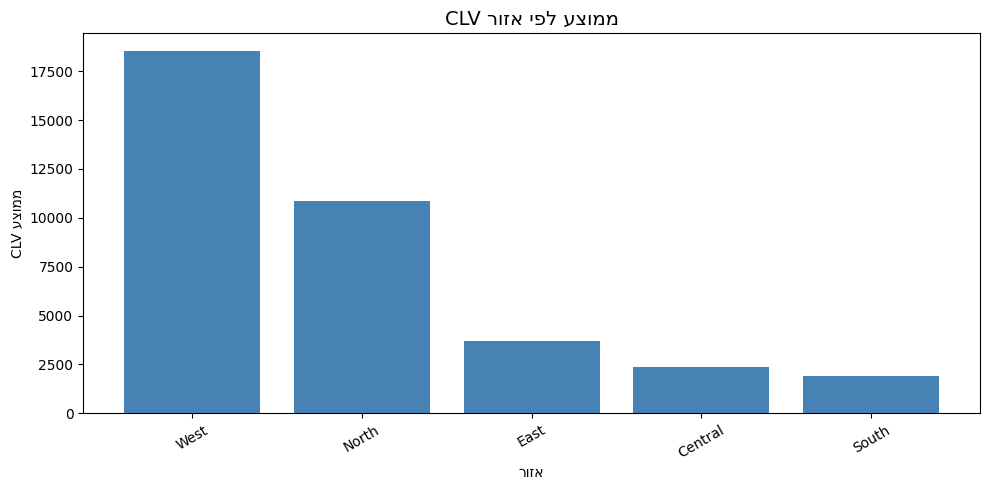

In [18]:
region_clv = Sales_Revenue.groupby('region')['customer_lifetime_value'].mean().sort_values(ascending=False)
print(region_clv.round(2))


plt.figure(figsize=(10,5))
plt.bar(region_clv.index, region_clv.values, color='steelblue')

plt.title(fix_text('CLV ממוצע לפי אזור'), fontsize=14)
plt.xlabel(fix_text('אזור'))
plt.ylabel(fix_text('CLV ממוצע'))
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### ממצא והמלצה עסקית — אזורים
- מערב מוביל בממוצע ערך של הלקוח לחברה, אך הכדאי לבדוק השפעה של  חריגים בודדים
- הדרום והמרכז מציגים ערך של הלקוח לחברה נמוך — ייתכן שיש בהם פוטנציאל לא מנוצל
- **המלצה:** להשקיע בחיזוק אזורי מערב ו-צפון, ולבחון אסטרטגיה ייחודית ל-דרום

---
## ניתוח ערך לקוח לפי סגמנט
### שאלה עסקית: מה ההבדל בערך בין סגמנטי הלקוחות?

customer_segment
Budget        280.4
Standard      651.6
Premium     13179.5
Name: customer_lifetime_value, dtype: float64


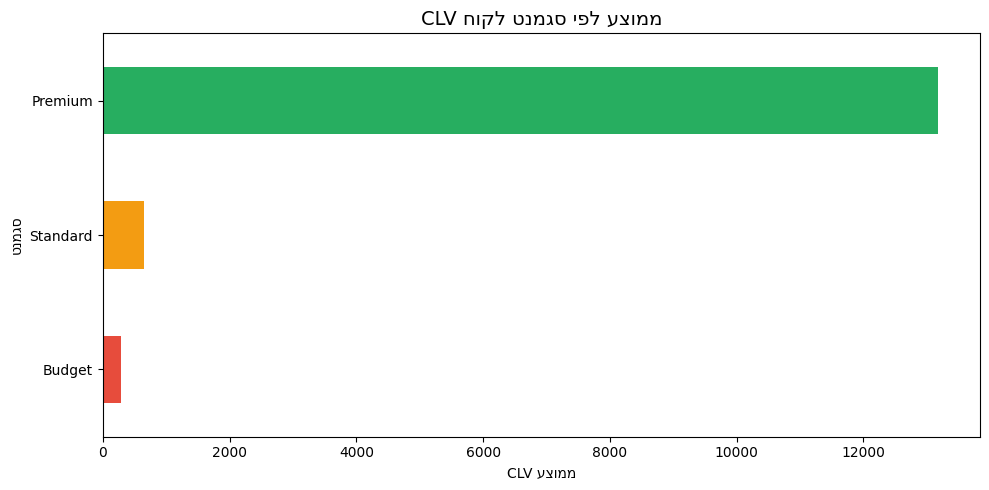

In [19]:
segment_analysis = Sales_Revenue.groupby('customer_segment')['customer_lifetime_value'].mean().sort_values(ascending=True)
print(segment_analysis.round(2))

colors = ['#e74c3c', '#f39c12', '#27ae60']  
segment_analysis.plot(kind='barh', figsize=(10, 5), color=colors)
plt.title(fix_text('CLV ממוצע לפי סגמנט לקוח'), fontsize=14)
plt.xlabel(fix_text('CLV ממוצע'))
plt.ylabel(fix_text('סגמנט'))
plt.tight_layout()
plt.show()

### ממצא והמלצה עסקית — סגמנטים
- לקוחות Premium מניבים ערך גבוה פי עשרות מ-Budget ו-Standard
- **המלצה:** להשקיע במשיכת לקוחות Premium ובהמרת Standard לPremium באמצעות תוכניות נאמנות

---
## ניתוח לפי קטגוריית מוצר
### שאלה עסקית: אילו מוצרים מניבים תשואה עודפת בכל ערוץ?

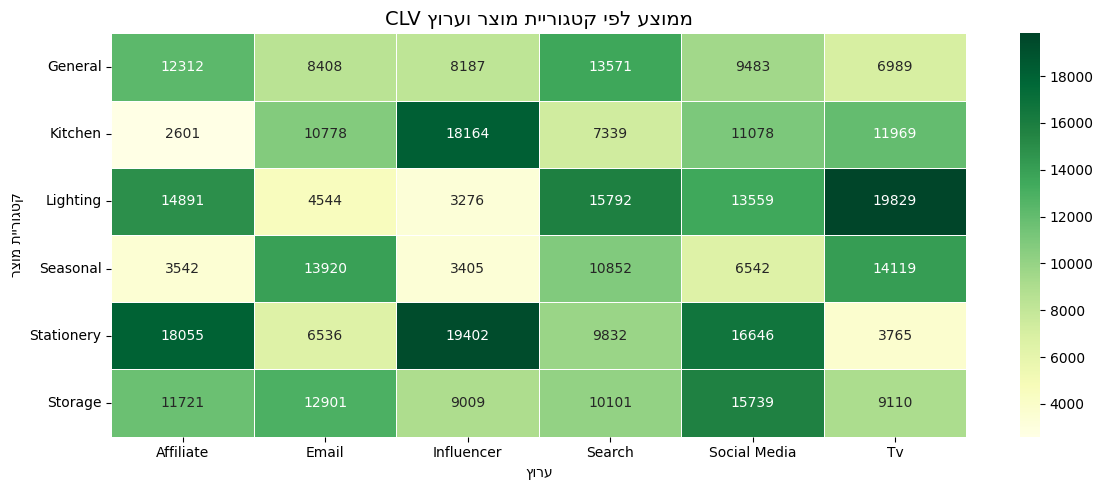

In [20]:
pivot_product = Sales_Revenue.pivot_table(
    values='customer_lifetime_value',
    index='product_category',
    columns='channel',
    aggfunc='mean'
).round(0)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_product, annot=True, fmt='.0f', cmap='YlGn', linewidths=0.5)
plt.title(fix_text('CLV ממוצע לפי קטגוריית מוצר וערוץ'), fontsize=14)
plt.xlabel(fix_text('ערוץ'))
plt.ylabel(fix_text('קטגוריית מוצר'))
plt.tight_layout()
plt.show()

### ממצא והמלצה עסקית — מוצרים

- **המלצה:** לקדם מוצרים דרך הערוצים בהם הם מצליחים

---
## פעילות לפי שעה ביום
### שאלה עסקית: מתי כדאי לפרסם? באיזה שעות יש הכי הרבה חשיפה?

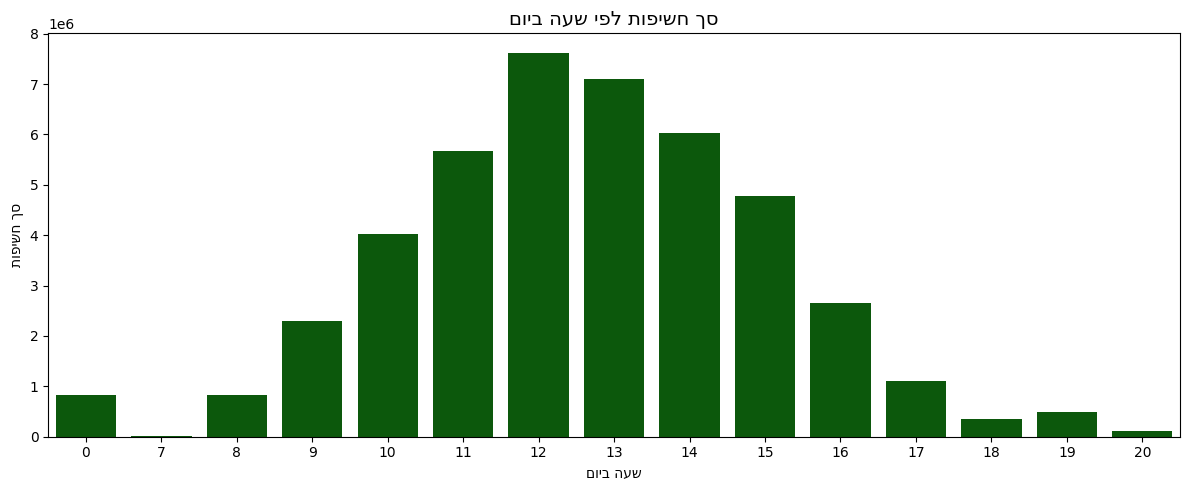

In [21]:
impressions_by_hour = Sales_Revenue.groupby('hour')['impressions'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=impressions_by_hour, x='hour', y='impressions', color='darkgreen')
plt.title(fix_text('סך חשיפות לפי שעה ביום'), fontsize=14)
plt.xlabel(fix_text('שעה ביום'))
plt.ylabel(fix_text('סך חשיפות'))
plt.tight_layout()
plt.show()

### ממצא והמלצה עסקית — שעות פעילות
- שעות השיא בחשיפות הן שעות הפרסום האפקטיביות ביותר
- **המלצה:** לתזמן קמפיינים לשעות הפעילות הגבוהות ולהפחית פרסום בשעות חלשות

---
## ניתוח עלות - תועלת  — CLV per Ad Spend
### שאלה עסקית: כמה ערך לקוח מקבלים על כל שקל שמשקיעים בפרסום?

              clv_per_spend  reach_per_spend
channel                                     
Affiliate           1716.57            55.32
Search              1486.44            51.71
Tv                  1439.57            66.47
Email               1360.77            54.36
Social Media        1111.07            63.21
Influencer          1070.15            65.93


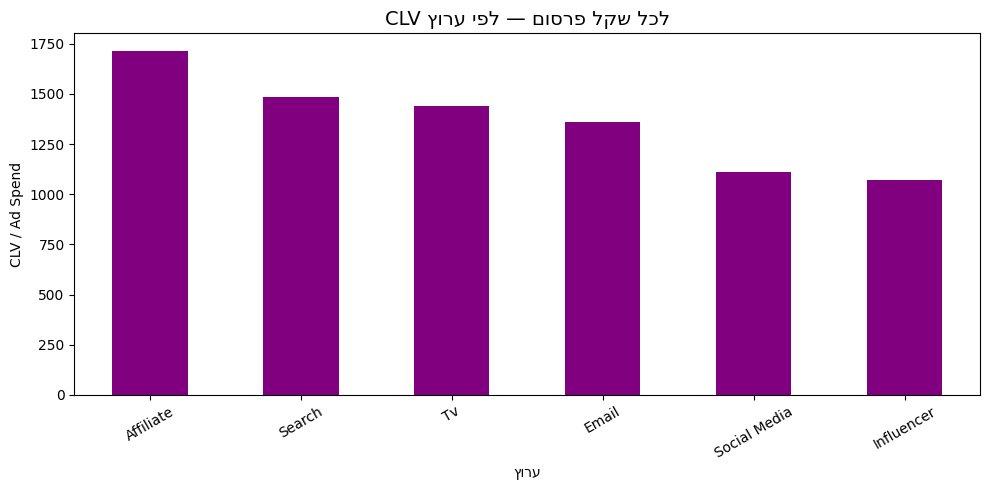

In [22]:
Sales_Revenue['clv_per_spend'] = (
    Sales_Revenue['customer_lifetime_value']
    / Sales_Revenue['ad_spend'].replace(0, np.nan)
)
Sales_Revenue['reach_per_spend'] = (
    Sales_Revenue['market_reach']
    / Sales_Revenue['ad_spend'].replace(0, np.nan)
)

eff_by_channel = Sales_Revenue.groupby('channel')[['clv_per_spend','reach_per_spend']].mean().round(2).sort_values('clv_per_spend', ascending=False)
print(eff_by_channel)

eff_by_channel['clv_per_spend'].plot(kind='bar', figsize=(10,5), color='purple')
plt.title(fix_text('CLV לכל שקל פרסום — לפי ערוץ'), fontsize=14)
plt.xlabel(fix_text('ערוץ'))
plt.ylabel(fix_text('CLV / Ad Spend'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### ממצא והמלצה עסקית — יעילות פרסום
- Affiliate ו-Search מציגים CLV לשקול הוצאת פרסום גבוה יותר
- **המלצה:** Affiliate ו-Search ולהפחית בערוצים עם ערך של הלקוח לחברה כנגד ההוצאות נמוך.להגדיל תקציב ב-

In [23]:
print(Sales_Revenue.columns)

Index(['id', 'date', 'region', 'channel', 'product_category',
       'customer_segment', 'ad_spend', 'price', 'discount_rate',
       'market_reach', 'impressions', 'click_through_rate',
       'competition_index', 'seasonality_index', 'campaign_duration_days',
       'customer_lifetime_value', 'year', 'month', 'quarter', 'day_of_week',
       'hour', 'year_month', 'revenue', 'roi', 'clv_per_spend',
       'reach_per_spend'],
      dtype='str')


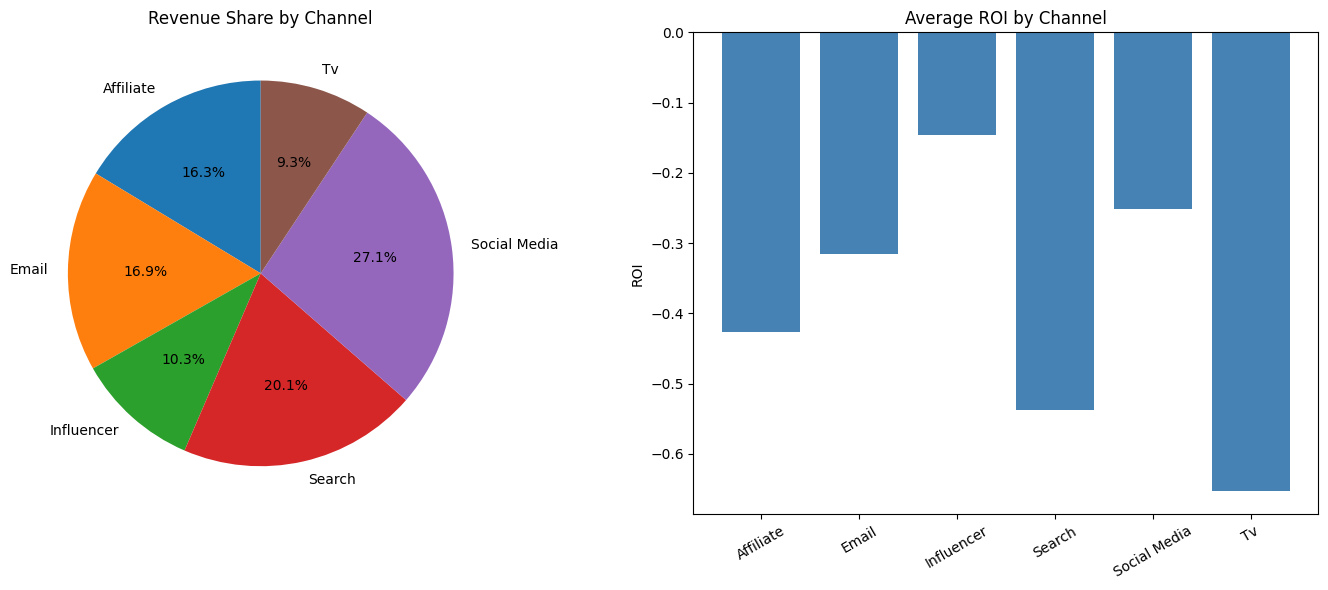

In [24]:
comparison = Sales_Revenue.groupby('channel').agg({
    'revenue':'sum',
    'roi':'mean'
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart - Revenue
axes[0].pie(
    comparison['revenue'],
    labels=comparison.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Revenue Share by Channel')

# Bar chart - ROI
axes[1].bar(
    comparison.index,
    comparison['roi'],
    color='steelblue'
)
axes[1].set_title('Average ROI by Channel')
axes[1].set_ylabel('ROI')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# מגמה לאורך השנים

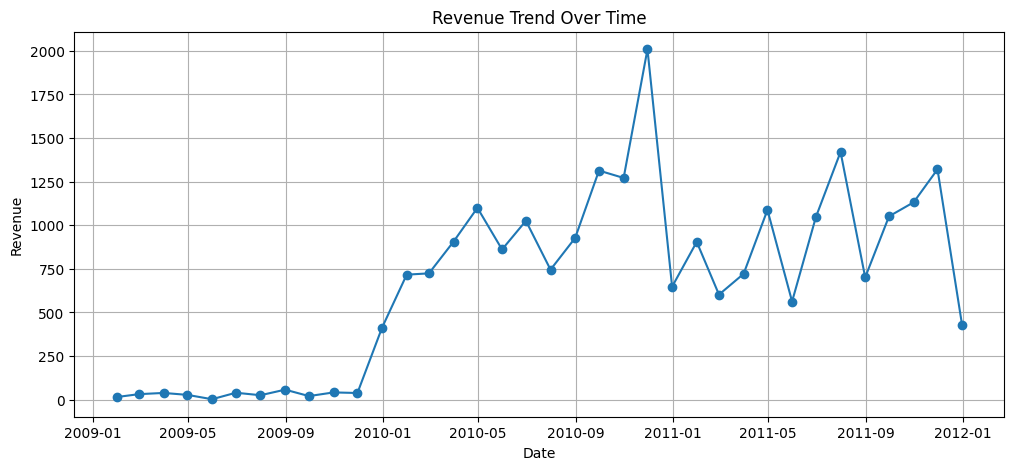

In [25]:
Sales_Revenue['date'] = pd.to_datetime(Sales_Revenue['date'])
monthly = Sales_Revenue.resample('ME', on='date')['revenue'].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values, marker='o')

plt.title('Revenue Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid()


---
## סיכום פעילות עסקית — Activity Summary

In [26]:
print("="*60)
print("       סיכום מנהלים — ניתוח נתוני מכירות")
print("="*60)

best_channel_clv    = Sales_Revenue.groupby('channel')['customer_lifetime_value'].mean().idxmax()
best_channel_roi    = roi_channel['roi'].idxmax()
best_region         = Sales_Revenue.groupby('region')['customer_lifetime_value'].mean().idxmax()
best_segment        = Sales_Revenue.groupby('customer_segment')['customer_lifetime_value'].mean().idxmax()
best_product        = Sales_Revenue.groupby('product_category')['revenue'].mean().idxmax()
peak_hour           = impressions_by_hour.loc[impressions_by_hour['impressions'].idxmax(), 'hour']

print (f"\n ערוץ עם CLV גבוה ביותר  : {best_channel_clv}")
print(f" ערוץ עם ROI גבוה ביותר   : {best_channel_roi}")
print(f" אזור מוביל                : {best_region}")
print(f" סגמנט מוביל               : {best_segment}")
print(f" קטגוריית מוצר מובילת      : {best_product}")
print(f" שעת פרסום אפקטיבית        : {peak_hour}-16")
print("\n" + "="*60)

       סיכום מנהלים — ניתוח נתוני מכירות

 ערוץ עם CLV גבוה ביותר  : Search
 ערוץ עם ROI גבוה ביותר   : Influencer
 אזור מוביל                : West
 סגמנט מוביל               : Premium
 קטגוריית מוצר מובילת      : Stationery
 שעת פרסום אפקטיבית        : 12-16

